# Twitter Sentiment Analysis


## 1. Introduction
This project focuses on analyzing Twitter data to determine the sentiment of users. The sentiments are classified as positive, negative, or neutral.

## 2. Problem Statement
The objective of this project is to classify tweets into different sentiment categories using machine learning techniques.

## 3. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

## 4. Data Loading


In [2]:
df = pd.read_csv("Twitter_Data.csv")

## 3. Data Exploration
In this step, we analyze the dataset structure and understand the data.

In [3]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [5]:
df.describe()

,category
count,162973.000000
mean,0.225436
std,0.781279
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [6]:
df.columns

Index(['clean_text', 'category'], dtype='object')

## 6. Data Preprocessing
This step involves handling missing values and preparing the data for analysis.

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

clean_text    0
category      0
dtype: int64

## 7. Feature Extraction
In this step, text data is converted into numerical form using CountVectorizer.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)

X = cv.fit_transform(df['clean_text']).toarray()
y = df['category']

## 8. Train-Test Split
The dataset is divided into training and testing sets.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
print(X.shape)
print(y.shape)

(162969, 5000)
(162969,)


## 9. Model Training
We use the Naive Bayes algorithm to train the sentiment classification model.

In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [14]:
y_pred = model.predict(X_test)

## 10. Model Evaluation
The model performance is evaluated using accuracy, confusion matrix, and classification report.

In [15]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8082775971037615


## 11. Visualization
This step visualizes the distribution of sentiment categories.

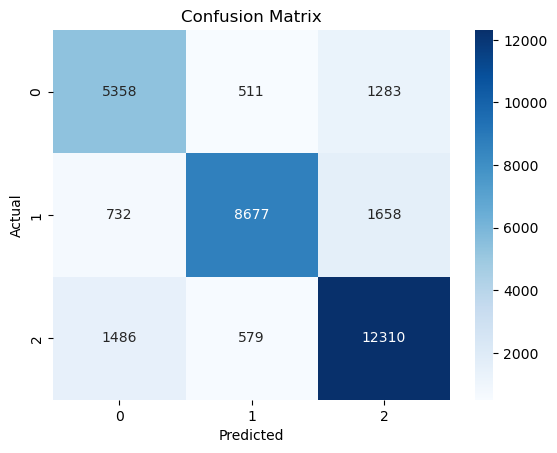

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.71      0.75      0.73      7152
         0.0       0.89      0.78      0.83     11067
         1.0       0.81      0.86      0.83     14375

    accuracy                           0.81     32594
   macro avg       0.80      0.80      0.80     32594
weighted avg       0.81      0.81      0.81     32594



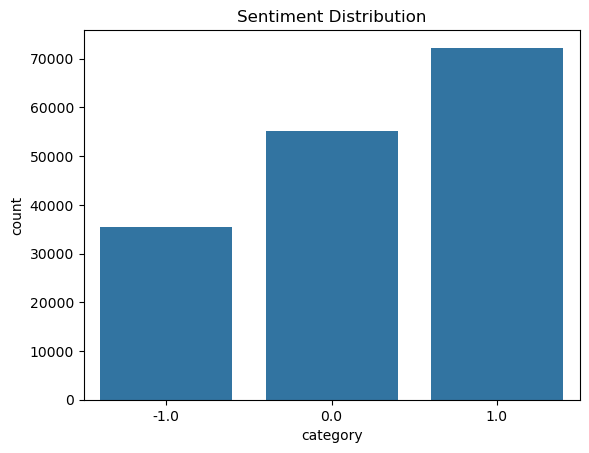

In [18]:
sns.countplot(x='category', data=df)
plt.title("Sentiment Distribution")
plt.show()

## 12. Custom Sentiment Prediction
This function allows us to predict sentiment for new input text.

In [19]:
def predict_sentiment(text):
    text_vec = cv.transform([text]).toarray()
    result = model.predict(text_vec)
    return result[0]

print(predict_sentiment("I love this product"))
print(predict_sentiment("This is very bad"))

1.0
-1.0


# Conclusion

The Twitter Sentiment Analysis model was developed using Naive Bayes algorithm.
The model achieved an accuracy of approximately 81%, indicating good performance.
It effectively classifies tweets into positive, negative, and neutral categories.
The system can be used to understand public opinion and trends.